<a href="https://colab.research.google.com/github/pantera-rosa/vuln-management-capstone/blob/jacqueline-branch/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [55]:
import os
import json
import subprocess
import requests
import pandas as pd
!pip install flatten_json
from flatten_json import flatten
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def json_to_pandas_df(data_json):
  # Attempt to convert the JSON data to a pandas DataFrame by flattening it
  try:
      data_json_flat = flatten(data_json)
      df = pd.DataFrame([data_json_flat]) # Wrap the flattened dictionary in a list
      display(df)
      return df
  except Exception as e:
      print(f"Error flattening and converting JSON to DataFrame: {e}")
      print("The JSON data might still be too complex or have inconsistent structures for full flattening.\n Consider manually extracting specific nested paths using json_normalize or exploring the JSON structure directly.")

In [3]:
def plot_hist(dictionary, x_label, y_label, title, sort=True, include_bar_labels=True):
  # Convert the dictionary to a pandas Series for easier plotting
  series = pd.Series(dictionary)

  # Sort the series by index
  if sort:
    series = series.sort_index()

  # Create a bar plot
  plt.figure(figsize=(12, 6))
  ax = series.plot(kind='bar')
  if include_bar_labels:
    for container in ax.containers:
      ax.bar_label(container, fmt='%g', label_type='edge', padding=3)
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)
  plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels overlapping
  plt.show()

## CVE Records

View 1 record:

In [ ]:
# Construct the URL for the CVE data in the cvelistv5 GitHub repository
cve_id = "CVE-2021-44228"
year = cve_id.split('-')[1] # Extract the year from the CVE ID
id_prefix = cve_id.split('-')[2][:-3] # Extract the all but the last 3 digits of the id from the CVE ID

In [ ]:
# The structure of the cvelistv5 repo is cves/{year}/{id_prefix}xxx/{cve_id}.json
cvelist_url = f"https://raw.githubusercontent.com/CVEProject/cvelistV5/refs/heads/main/cves/{year}/{id_prefix}xxx/{cve_id}.json"
cvelist_url

'https://raw.githubusercontent.com/CVEProject/cvelistV5/refs/heads/main/cves/2015/44xxx/CVE-2021-44228.json'

In [ ]:
# Use the requests library to fetch and parse the data
cvelist_data_json = requests.get(cvelist_url).json()

# Display the fetched data
if cvelist_data_json:
    display(cvelist_data_json)
else:
    print(f"Could not fetch or parse data for {cve_id} from cvelistv5.")

{'dataType': 'CVE_RECORD',
 'dataVersion': '5.1',
 'cveMetadata': {'state': 'PUBLISHED',
  'cveId': 'CVE-2021-44228',
  'assignerOrgId': 'f0158376-9dc2-43b6-827c-5f631a4d8d09',
  'assignerShortName': 'apache',
  'dateUpdated': '2025-07-30T01:37:52.215Z',
  'dateReserved': '2021-11-26T00:00:00.000Z',
  'datePublished': '2021-12-10T00:00:00.000Z'},
 'containers': {'cna': {'title': 'Apache Log4j2 JNDI features do not protect against attacker controlled LDAP and other JNDI related endpoints',
   'providerMetadata': {'orgId': 'f0158376-9dc2-43b6-827c-5f631a4d8d09',
    'shortName': 'apache',
    'dateUpdated': '2023-04-03T00:00:00.000Z'},
   'descriptions': [{'lang': 'en',
     'value': 'Apache Log4j2 2.0-beta9 through 2.15.0 (excluding security releases 2.12.2, 2.12.3, and 2.3.1) JNDI features used in configuration, log messages, and parameters do not protect against attacker controlled LDAP and other JNDI related endpoints. An attacker who can control log messages or log message parameter

In [ ]:
cvelist_df = json_to_pandas_df(cvelist_data_json)

,dataType,dataVersion,cveMetadata_state,cveMetadata_cveId,cveMetadata_assignerOrgId,cveMetadata_assignerShortName,cveMetadata_dateUpdated,cveMetadata_dateReserved,cveMetadata_datePublished,containers_cna_title,...,containers_adp_1_metrics_2_other_type,containers_adp_1_metrics_2_other_content_dateAdded,containers_adp_1_metrics_2_other_content_reference,containers_adp_1_timeline_0_time,containers_adp_1_timeline_0_lang,containers_adp_1_timeline_0_value,containers_adp_1_title,containers_adp_1_providerMetadata_orgId,containers_adp_1_providerMetadata_shortName,containers_adp_1_providerMetadata_dateUpdated
0,CVE_RECORD,5.1,PUBLISHED,CVE-2021-44228,f0158376-9dc2-43b6-827c-5f631a4d8d09,apache,2025-07-30T01:37:52.215Z,2021-11-26T00:00:00.000Z,2021-12-10T00:00:00.000Z,Apache Log4j2 JNDI features do not protect aga...,...,kev,2021-12-10,https://www.cisa.gov/known-exploited-vulnerabi...,2021-12-10T00:00:00+00:00,en,CVE-2021-44228 added to CISA KEV,CISA ADP Vulnrichment,134c704f-9b21-4f2e-91b3-4a467353bcc0,CISA-ADP,2025-07-30T01:37:52.215Z


Count records:\
Due to GitHub API request limitations, results are incomplete.

In [ ]:
# GitHub API: get repo tree (recursive).
url = "https://api.github.com/repos/CVEProject/cvelistV5/git/trees/main?recursive=1"
exclude_files = {"delta.json", "deltaLog.json"}

resp = requests.get(url)
resp.raise_for_status()
data = resp.json()

total_count = 0
by_year = defaultdict(int)

for item in data.get("tree", []):
    if item["type"] == "blob" and item["path"].startswith("cves/"):
        filename = item["path"].split("/")[-1]
        if filename not in exclude_files:
            total_count += 1

            # check if path has "cves/YYYY/"
            parts = item["path"].split("/")
            if len(parts) > 1 and parts[1].isdigit():
                year = parts[1]
                by_year[year] += 1

print("Total CVE leaf files:", total_count)
print("\nCounts by year:")
for year in sorted(by_year.keys()):
    print(year, by_year[year])

Total CVE leaf files: 77106

Counts by year:
1999 1579
2000 1242
2001 1556
2002 2393
2003 1555
2004 2707
2005 4769
2006 7143
2007 6580
2008 7177
2009 5052
2010 5244
2011 4886
2012 5937
2013 6819
2014 9000
2015 3467


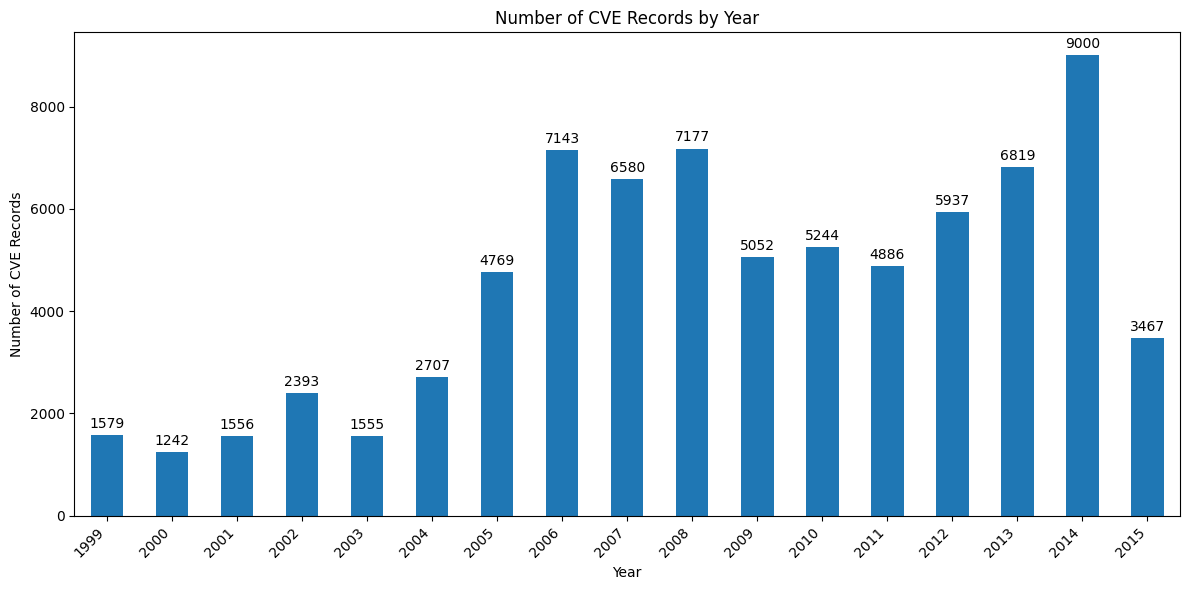

In [ ]:
plot_hist(by_year, 'Year', 'Number of CVE Records', 'Number of CVE Records by Year')

Count from local machine:

```
$ git ls-files cves/ | grep -E '[0-9]+\/.*CVE-.*json' | wc -l
311490
```





```
$ git ls-files cves | \
   grep -vE 'delta\.json$|deltaLog\.json$' | \
   awk -F/ '{print $2}' | \
   sort | uniq -c | \
   awk '{print "\""$2"\": "$1","}' | \
   sed '$ s/,$//' | \
   awk 'BEGIN{print "{"} {print} END{print "}"}'
{
"1999": 1579,
"2000": 1242,
"2001": 1556,
"2002": 2393,
"2003": 1555,
"2004": 2707,
"2005": 4769,
"2006": 7143,
"2007": 6580,
"2008": 7177,
"2009": 5052,
"2010": 5244,
"2011": 4886,
"2012": 5937,
"2013": 6819,
"2014": 9000,
"2015": 8766,
"2016": 10560,
"2017": 17024,
"2018": 17495,
"2019": 17082,
"2020": 20640,
"2021": 23095,
"2022": 26909,
"2023": 30158,
"2024": 38674,
"2025": 27448
}
```



In [ ]:
by_year = {
"1999": 1579,
"2000": 1242,
"2001": 1556,
"2002": 2393,
"2003": 1555,
"2004": 2707,
"2005": 4769,
"2006": 7143,
"2007": 6580,
"2008": 7177,
"2009": 5052,
"2010": 5244,
"2011": 4886,
"2012": 5937,
"2013": 6819,
"2014": 9000,
"2015": 8766,
"2016": 10560,
"2017": 17024,
"2018": 17495,
"2019": 17082,
"2020": 20640,
"2021": 23095,
"2022": 26909,
"2023": 30158,
"2024": 38674,
"2025": 27448
}

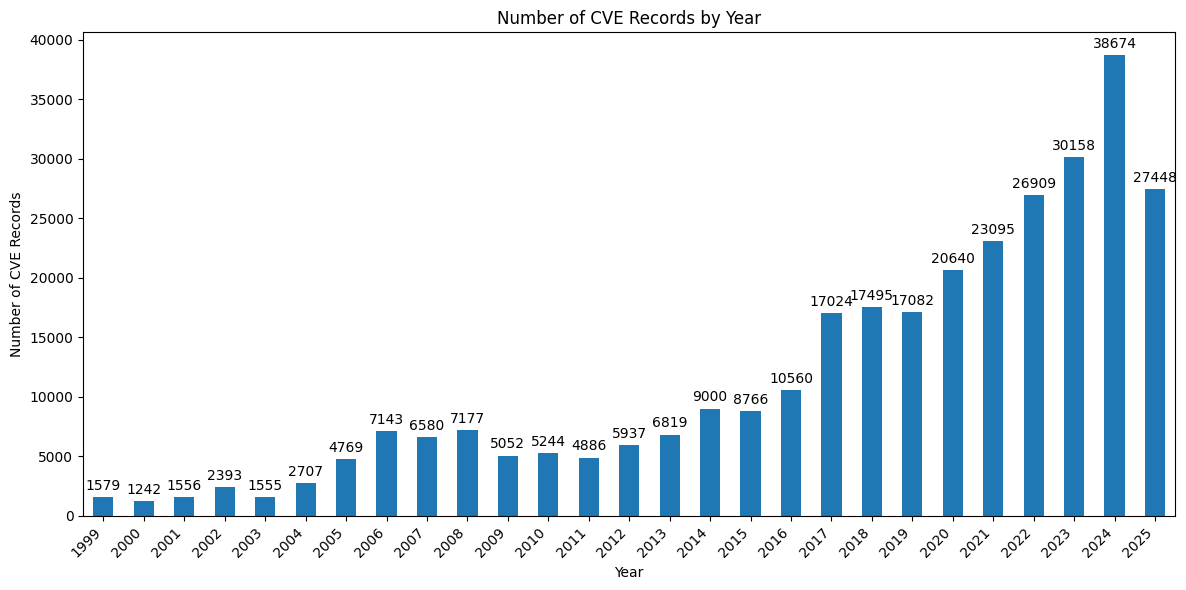

In [ ]:
plot_hist(by_year, 'Year', 'Number of CVE Records', 'Number of CVE Records by Year')

## NVD Data Feeds

View 1 record:

In [ ]:
nvd_url = f"https://services.nvd.nist.gov/rest/json/cves/2.0?cveId={cve_id}"

In [ ]:
nvd_data_json = requests.get(nvd_url).json()
nvd_data_json

{'resultsPerPage': 1,
 'startIndex': 0,
 'totalResults': 1,
 'format': 'NVD_CVE',
 'version': '2.0',
 'timestamp': '2025-09-24T02:49:50.214',
 'vulnerabilities': [{'cve': {'id': 'CVE-2021-44228',
    'sourceIdentifier': 'security@apache.org',
    'published': '2021-12-10T10:15:09.143',
    'lastModified': '2025-08-08T18:52:00.230',
    'vulnStatus': 'Analyzed',
    'cveTags': [],
    'descriptions': [{'lang': 'en',
      'value': 'Apache Log4j2 2.0-beta9 through 2.15.0 (excluding security releases 2.12.2, 2.12.3, and 2.3.1) JNDI features used in configuration, log messages, and parameters do not protect against attacker controlled LDAP and other JNDI related endpoints. An attacker who can control log messages or log message parameters can execute arbitrary code loaded from LDAP servers when message lookup substitution is enabled. From log4j 2.15.0, this behavior has been disabled by default. From version 2.16.0 (along with 2.12.2, 2.12.3, and 2.3.1), this functionality has been complet

In [ ]:
nvd_df = json_to_pandas_df(nvd_data_json)

,resultsPerPage,startIndex,totalResults,format,version,timestamp,vulnerabilities_0_cve_id,vulnerabilities_0_cve_sourceIdentifier,vulnerabilities_0_cve_published,vulnerabilities_0_cve_lastModified,...,vulnerabilities_0_cve_references_115_source,vulnerabilities_0_cve_references_115_tags_0,vulnerabilities_0_cve_references_116_url,vulnerabilities_0_cve_references_116_source,vulnerabilities_0_cve_references_116_tags_0,vulnerabilities_0_cve_references_116_tags_1,vulnerabilities_0_cve_references_117_url,vulnerabilities_0_cve_references_117_source,vulnerabilities_0_cve_references_117_tags_0,vulnerabilities_0_cve_references_117_tags_1
0,1,0,1,NVD_CVE,2.0,2025-09-24T02:49:50.214,CVE-2021-44228,security@apache.org,2021-12-10T10:15:09.143,2025-08-08T18:52:00.230,...,af854a3a-2127-422b-91ae-364da2661108,Third Party Advisory,https://www.oracle.com/security-alerts/cpuapr2...,af854a3a-2127-422b-91ae-364da2661108,Patch,Third Party Advisory,https://www.oracle.com/security-alerts/cpujan2...,af854a3a-2127-422b-91ae-364da2661108,Patch,Third Party Advisory


Count records:

In [ ]:
total_nvd_count = requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&resultsPerPage=1").json()["totalResults"]
total_nvd_count

295413

In [ ]:
cvssV2Severity_counts = {
    'LOW': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV2Severity=LOW&resultsPerPage=1").json()["totalResults"],
    'MEDIUM': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV2Severity=MEDIUM&resultsPerPage=1").json()["totalResults"],
    'HIGH': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV2Severity=HIGH&resultsPerPage=1").json()["totalResults"]
}
cvssV2Severity_counts['UNSCORED'] = total_nvd_count - sum(cvssV2Severity_counts.values())

In [ ]:
cvssV3Severity_counts = {
    'LOW': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV3Severity=LOW&resultsPerPage=1").json()["totalResults"],
    'MEDIUM': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV3Severity=MEDIUM&resultsPerPage=1").json()["totalResults"],
    'HIGH': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV3Severity=HIGH&resultsPerPage=1").json()["totalResults"],
    'CRITICAL': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV3Severity=CRITICAL&resultsPerPage=1").json()["totalResults"]
}
cvssV3Severity_counts['UNSCORED'] = total_nvd_count - sum(cvssV3Severity_counts.values())

In [ ]:
cvssV4Severity_counts = {
    'LOW': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=LOW&resultsPerPage=1").json()["totalResults"],
    'MEDIUM': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=MEDIUM&resultsPerPage=1").json()["totalResults"],
    'HIGH': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=HIGH&resultsPerPage=1").json()["totalResults"],
    'CRITICAL': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=CRITICAL&resultsPerPage=1").json()["totalResults"]
}
cvssV4Severity_counts['UNSCORED'] = total_nvd_count - sum(cvssV4Severity_counts.values())

In [ ]:
cveTag_counts = {
    "disputed": requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cveTag=disputed&resultsPerPage=1").json()["totalResults"],
    "unsupported-when-assigned": requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cveTag=unsupported-when-assigned&resultsPerPage=1").json()["totalResults"],
    "exclusively-hosted-service": requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cveTag=exclusively-hosted-service&resultsPerPage=1").json()["totalResults"],
}
#cveTag_counts['untagged'] = total_nvd_count - sum(cveTag_counts.values())

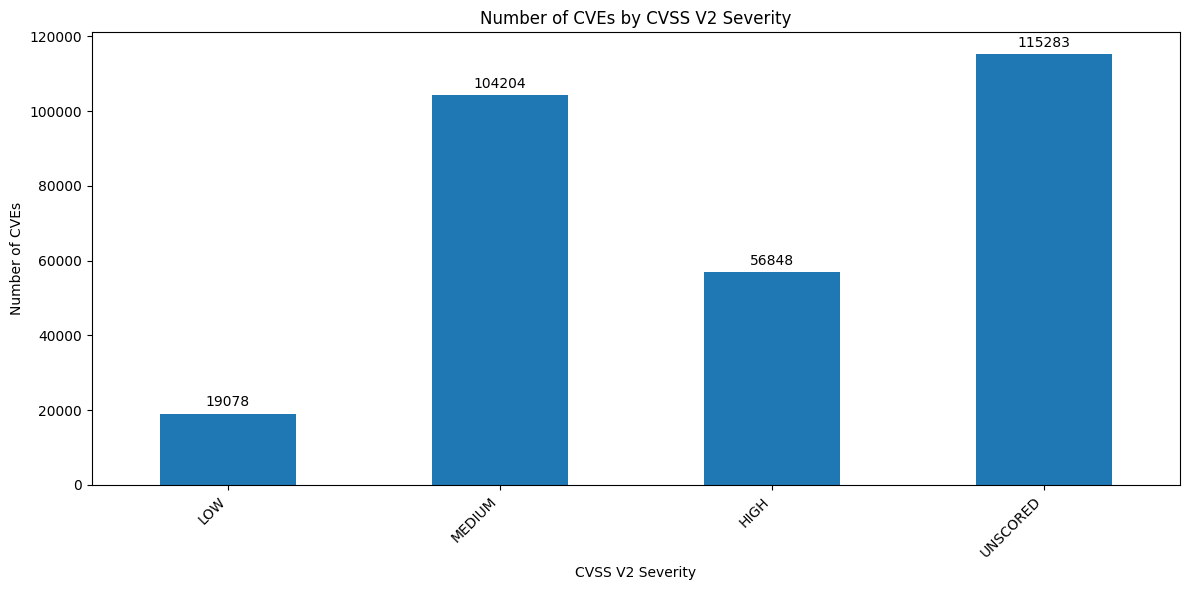

In [ ]:
plot_hist(cvssV2Severity_counts, "CVSS V2 Severity", "Number of CVEs", "Number of CVEs by CVSS V2 Severity", sort=False)

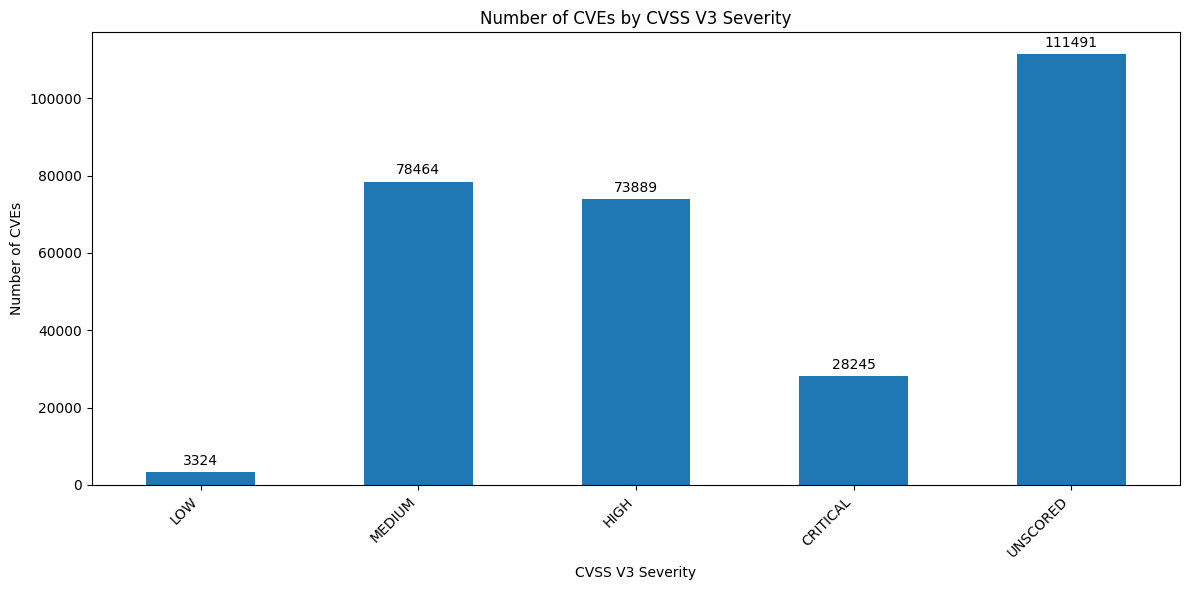

In [ ]:
plot_hist(cvssV3Severity_counts, "CVSS V3 Severity", "Number of CVEs", "Number of CVEs by CVSS V3 Severity", sort=False)

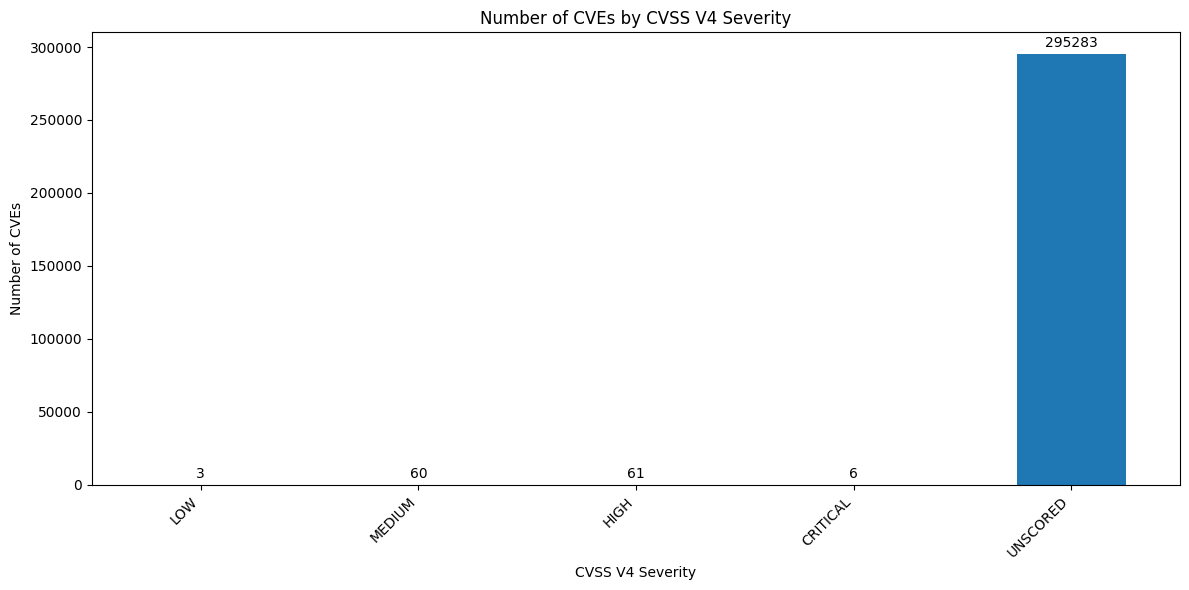

In [ ]:
plot_hist(cvssV4Severity_counts, "CVSS V4 Severity", "Number of CVEs", "Number of CVEs by CVSS V4 Severity", sort=False)

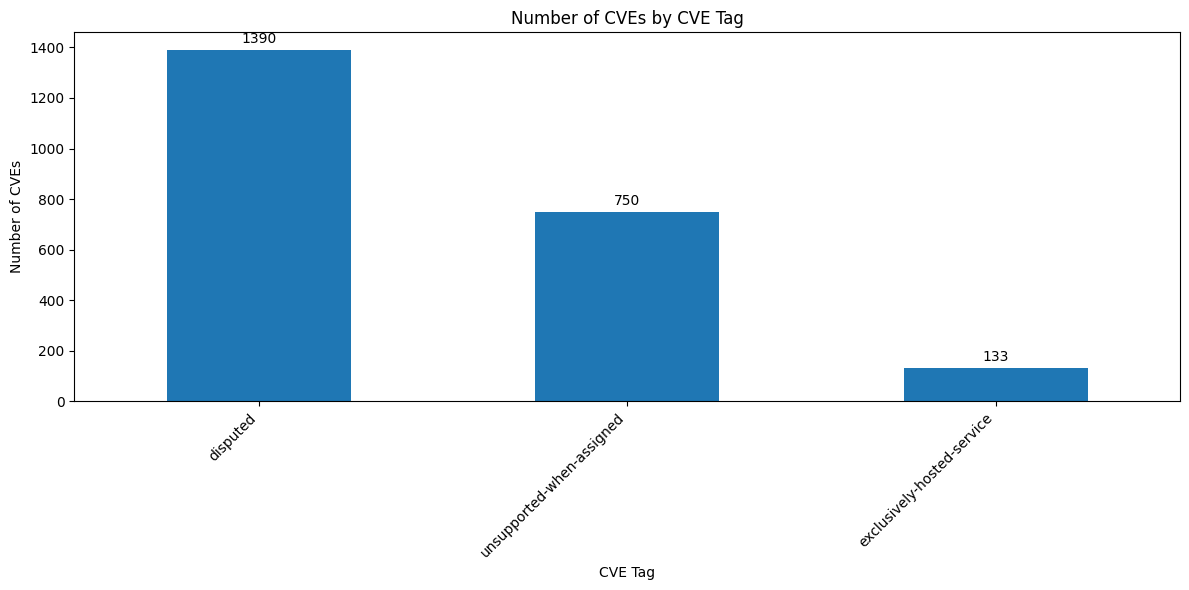

In [ ]:
plot_hist(cveTag_counts, "CVE Tag", "Number of CVEs", "Number of CVEs by CVE Tag", sort=False)

## EPSS Data

In [ ]:
epss_url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
epss_url

'https://api.first.org/data/v1/epss?cve=CVE-2021-44228'

In [ ]:
epss_data_json = requests.get(epss_url).json()
epss_data_json

{'status': 'OK',
 'status-code': 200,
 'version': '1.0',
 'access': 'public',
 'total': 1,
 'offset': 0,
 'limit': 100,
 'data': [{'cve': 'CVE-2021-44228',
   'epss': '0.943580000',
   'percentile': '0.999560000',
   'date': '2025-09-23'}]}

## OSV to release tag flow




In [ ]:
osv_url = f"https://api.osv.dev/v1/vulns/{cve_id}"

In [ ]:
osv_json = requests.get(osv_url).json()
osv_json

{'id': 'CVE-2021-44228',
 'details': 'Apache Log4j2 2.0-beta9 through 2.15.0 (excluding security releases 2.12.2, 2.12.3, and 2.3.1) JNDI features used in configuration, log messages, and parameters do not protect against attacker controlled LDAP and other JNDI related endpoints. An attacker who can control log messages or log message parameters can execute arbitrary code loaded from LDAP servers when message lookup substitution is enabled. From log4j 2.15.0, this behavior has been disabled by default. From version 2.16.0 (along with 2.12.2, 2.12.3, and 2.3.1), this functionality has been completely removed. Note that this vulnerability is specific to log4j-core and does not affect log4net, log4cxx, or other Apache Logging Services projects.',
 'aliases': ['GHSA-jfh8-c2jp-5v3q'],
 'modified': '2025-08-26T06:32:51.290234Z',
 'published': '2021-12-10T10:15:09Z',
 'related': ['MGASA-2021-0556',
  'SUSE-SU-2021:4096-1',
  'SUSE-SU-2021:4097-1',
  'openSUSE-SU-2021:1577-1',
  'openSUSE-SU-2

In [ ]:
ghsa_id = osv_json['aliases'][0]
ghsa_id

'GHSA-jfh8-c2jp-5v3q'

In [ ]:
ghsa_url = f"https://api.github.com/advisories/{ghsa_id}"
ghsa_url

'https://api.github.com/advisories/GHSA-jfh8-c2jp-5v3q'

In [ ]:
ghsa_json = requests.get(ghsa_url).json()
ghsa_json

{'ghsa_id': 'GHSA-jfh8-c2jp-5v3q',
 'cve_id': 'CVE-2021-44228',
 'url': 'https://api.github.com/advisories/GHSA-jfh8-c2jp-5v3q',
 'html_url': 'https://github.com/advisories/GHSA-jfh8-c2jp-5v3q',
 'summary': 'Remote code injection in Log4j',
 'description': "# Summary\n\nLog4j versions prior to 2.16.0 are subject to a remote code execution vulnerability via the ldap JNDI parser.\nAs per [Apache's Log4j security guide](https://logging.apache.org/log4j/2.x/security.html): Apache Log4j2 <=2.14.1 JNDI features used in configuration, log messages, and parameters do not protect against attacker controlled LDAP and other JNDI related endpoints. An attacker who can control log messages or log message parameters can execute arbitrary code loaded from LDAP servers when message lookup substitution is enabled. From log4j 2.16.0, this behavior has been disabled by default.\n\nLog4j version 2.15.0 contained an earlier fix for the vulnerability, but that patch did not disable attacker-controlled JNDI 

In [ ]:
github_link = ghsa_json['source_code_location']
github_link

'https://github.com/apache/logging-log4j2'

In [ ]:
pr_link = None
for ref in ghsa_json['references']:
  if ref.startswith(github_link) and "/pull/" in ref:
    pr_link = ref
    break
pr_link

'https://github.com/apache/logging-log4j2/pull/608'

In [ ]:
github_api_url = f"https://api.github.com/repos/apache/logging-log4j2/pulls/608"

In [ ]:
github_api_json = requests.get(github_api_url).json()
github_api_json

{'url': 'https://api.github.com/repos/apache/logging-log4j2/pulls/608',
 'id': 791329956,
 'node_id': 'PR_kwDOAKJSSM4vKryk',
 'html_url': 'https://github.com/apache/logging-log4j2/pull/608',
 'diff_url': 'https://github.com/apache/logging-log4j2/pull/608.diff',
 'patch_url': 'https://github.com/apache/logging-log4j2/pull/608.patch',
 'issue_url': 'https://api.github.com/repos/apache/logging-log4j2/issues/608',
 'number': 608,
 'state': 'closed',
 'locked': False,
 'title': 'Restrict LDAP access via JNDI',
 'user': {'login': 'rgoers',
  'id': 120415,
  'node_id': 'MDQ6VXNlcjEyMDQxNQ==',
  'avatar_url': 'https://avatars.githubusercontent.com/u/120415?v=4',
  'gravatar_id': '',
  'url': 'https://api.github.com/users/rgoers',
  'html_url': 'https://github.com/rgoers',
  'followers_url': 'https://api.github.com/users/rgoers/followers',
  'following_url': 'https://api.github.com/users/rgoers/following{/other_user}',
  'gists_url': 'https://api.github.com/users/rgoers/gists{/gist_id}',
  'sta

In [ ]:
merge_commit_sha = github_api_json['merge_commit_sha']
merge_commit_sha

'c77b3cb39312b83b053d23a2158b99ac7de44dd3'

## Grype scan to pandas dataframe

In [106]:
with open('/content/verademo_sbom_grype_all_scan.json', 'r') as f:
    sbom_data = json.load(f)

# You might need to adjust this based on the structure of your JSON
sbom_df = pd.json_normalize(sbom_data['matches'])
display(sbom_df.head())

,relatedVulnerabilities,matchDetails,vulnerability.id,vulnerability.dataSource,vulnerability.namespace,vulnerability.severity,vulnerability.urls,vulnerability.description,vulnerability.cvss,vulnerability.knownExploited,...,artifact.licenses,artifact.cpes,artifact.purl,artifact.upstreams,artifact.metadataType,artifact.metadata.virtualPath,artifact.metadata.pomArtifactID,artifact.metadata.pomGroupID,artifact.metadata.manifestName,artifact.metadata.archiveDigests
0,"[{'id': 'CVE-2022-22965', 'dataSource': 'https...","[{'type': 'exact-direct-match', 'matcher': 'ja...",GHSA-36p3-wjmg-h94x,https://github.com/advisories/GHSA-36p3-wjmg-h94x,github:language:java,Critical,[],Remote Code Execution in Spring Framework,"[{'type': 'Secondary', 'version': '3.1', 'vect...","[{'cve': 'CVE-2022-22965', 'vendorProject': 'V...",...,[],[cpe:2.3:a:org.springframework.boot:spring-boo...,pkg:maven/org.springframework.boot/spring-boot...,[],JavaMetadata,,spring-boot-starter-web,org.springframework.boot,,None
1,"[{'id': 'CVE-2015-7501', 'dataSource': 'https:...","[{'type': 'exact-direct-match', 'matcher': 'ja...",GHSA-fjq5-5j5f-mvxh,https://github.com/advisories/GHSA-fjq5-5j5f-mvxh,github:language:java,Critical,[],Deserialization of Untrusted Data in Apache co...,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,...,[],[cpe:2.3:a:apache:commons-collections4:4.0:*:*...,pkg:maven/org.apache.commons/commons-collectio...,[],JavaMetadata,,commons-collections4,org.apache.commons,,None
2,"[{'id': 'CVE-2024-8698', 'dataSource': 'https:...","[{'type': 'exact-direct-match', 'matcher': 'ja...",GHSA-xgfv-xpx8-qhcr,https://github.com/advisories/GHSA-xgfv-xpx8-qhcr,github:language:java,High,[],Improper Verification of SAML Responses Leadin...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,...,[],[cpe:2.3:a:keycloak-saml-core:keycloak-saml-co...,pkg:maven/org.keycloak/keycloak-saml-core@1.8....,[],JavaMetadata,,keycloak-saml-core,org.keycloak,,None
3,"[{'id': 'CVE-2023-24998', 'dataSource': 'https...","[{'type': 'exact-direct-match', 'matcher': 'ja...",GHSA-hfrx-6qgj-fp6c,https://github.com/advisories/GHSA-hfrx-6qgj-fp6c,github:language:java,High,[],Apache Commons FileUpload denial of service vu...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,...,[],[cpe:2.3:a:commons-fileupload:commons-fileuplo...,pkg:maven/commons-fileupload/commons-fileuploa...,[],JavaMetadata,,commons-fileupload,commons-fileupload,,None
4,"[{'id': 'CVE-2016-1000031', 'dataSource': 'htt...","[{'type': 'exact-direct-match', 'matcher': 'ja...",GHSA-7x9j-7223-rg5m,https://github.com/advisories/GHSA-7x9j-7223-rg5m,github:language:java,Critical,[],Improper Access Control in commons-fileupload,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,...,[],[cpe:2.3:a:commons-fileupload:commons-fileuplo...,pkg:maven/commons-fileupload/commons-fileuploa...,[],JavaMetadata,,commons-fileupload,commons-fileupload,,None


In [83]:
sbom_expanded_df = sbom_df.explode(["relatedVulnerabilities", "matchDetails", "vulnerability.epss"])
sbom_expanded_df

,relatedVulnerabilities,matchDetails,vulnerability.id,vulnerability.dataSource,vulnerability.namespace,vulnerability.severity,vulnerability.urls,vulnerability.description,vulnerability.cvss,vulnerability.knownExploited,...,artifact.licenses,artifact.cpes,artifact.purl,artifact.upstreams,artifact.metadataType,artifact.metadata.virtualPath,artifact.metadata.pomArtifactID,artifact.metadata.pomGroupID,artifact.metadata.manifestName,artifact.metadata.archiveDigests
0,"{'id': 'CVE-2022-22965', 'dataSource': 'https:...","{'type': 'exact-direct-match', 'matcher': 'jav...",GHSA-36p3-wjmg-h94x,https://github.com/advisories/GHSA-36p3-wjmg-h94x,github:language:java,Critical,[],Remote Code Execution in Spring Framework,"[{'type': 'Secondary', 'version': '3.1', 'vect...","[{'cve': 'CVE-2022-22965', 'vendorProject': 'V...",...,[],[cpe:2.3:a:org.springframework.boot:spring-boo...,pkg:maven/org.springframework.boot/spring-boot...,[],JavaMetadata,,spring-boot-starter-web,org.springframework.boot,,None
1,"{'id': 'CVE-2015-7501', 'dataSource': 'https:/...","{'type': 'exact-direct-match', 'matcher': 'jav...",GHSA-fjq5-5j5f-mvxh,https://github.com/advisories/GHSA-fjq5-5j5f-mvxh,github:language:java,Critical,[],Deserialization of Untrusted Data in Apache co...,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,...,[],[cpe:2.3:a:apache:commons-collections4:4.0:*:*...,pkg:maven/org.apache.commons/commons-collectio...,[],JavaMetadata,,commons-collections4,org.apache.commons,,None
2,"{'id': 'CVE-2024-8698', 'dataSource': 'https:/...","{'type': 'exact-direct-match', 'matcher': 'jav...",GHSA-xgfv-xpx8-qhcr,https://github.com/advisories/GHSA-xgfv-xpx8-qhcr,github:language:java,High,[],Improper Verification of SAML Responses Leadin...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,...,[],[cpe:2.3:a:keycloak-saml-core:keycloak-saml-co...,pkg:maven/org.keycloak/keycloak-saml-core@1.8....,[],JavaMetadata,,keycloak-saml-core,org.keycloak,,None
3,"{'id': 'CVE-2023-24998', 'dataSource': 'https:...","{'type': 'exact-direct-match', 'matcher': 'jav...",GHSA-hfrx-6qgj-fp6c,https://github.com/advisories/GHSA-hfrx-6qgj-fp6c,github:language:java,High,[],Apache Commons FileUpload denial of service vu...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,...,[],[cpe:2.3:a:commons-fileupload:commons-fileuplo...,pkg:maven/commons-fileupload/commons-fileuploa...,[],JavaMetadata,,commons-fileupload,commons-fileupload,,None
4,"{'id': 'CVE-2016-1000031', 'dataSource': 'http...","{'type': 'exact-direct-match', 'matcher': 'jav...",GHSA-7x9j-7223-rg5m,https://github.com/advisories/GHSA-7x9j-7223-rg5m,github:language:java,Critical,[],Improper Access Control in commons-fileupload,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,...,[],[cpe:2.3:a:commons-fileupload:commons-fileuplo...,pkg:maven/commons-fileupload/commons-fileuploa...,[],JavaMetadata,,commons-fileupload,commons-fileupload,,None
5,"{'id': 'CVE-2015-6420', 'dataSource': 'https:/...","{'type': 'exact-direct-match', 'matcher': 'jav...",GHSA-6hgm-866r-3cjv,https://github.com/advisories/GHSA-6hgm-866r-3cjv,github:language:java,High,[],Insecure Deserialization in Apache Commons Col...,[],NaN,...,[],[cpe:2.3:a:apache:commons-collections4:4.0:*:*...,pkg:maven/org.apache.commons/commons-collectio...,[],JavaMetadata,,commons-collections4,org.apache.commons,,None
6,"{'id': 'CVE-2018-3258', 'dataSource': 'https:/...","{'type': 'exact-direct-match', 'matcher': 'jav...",GHSA-4vrv-ch96-6h42,https://github.com/advisories/GHSA-4vrv-ch96-6h42,github:language:java,High,[],Improper Privilege Management in MySQL Connect...,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,...,[],[cpe:2.3:a:mysql-connector-java:mysql-connecto...,pkg:maven/mysql/mysql-connector-java@5.1.48,[],JavaMetadata,,mysql-connector-java,mysql,,None
7,"{'id': 'CVE-2015-0886', 'dataSource': 'https:/...","{'type': 'exact-direct-match', 'matcher': 'jav...",GHSA-9h6p-92jq-888x,https://github.com/advisories/GHSA-9h6p-92jq-888x,github:language

In [84]:
sbom_extracted_df = pd.concat([
    sbom_expanded_df.drop('relatedVulnerabilities', axis=1),
    pd.json_normalize(sbom_expanded_df['relatedVulnerabilities']).add_prefix('relatedVulnerabilities.')
], axis=1)
sbom_extracted_df = pd.concat([
    sbom_extracted_df.drop('matchDetails', axis=1),
    pd.json_normalize(sbom_extracted_df['matchDetails']).add_prefix('matchDetails.')
], axis=1)
sbom_extracted_df = pd.concat([
    sbom_extracted_df.drop('vulnerability.epss', axis=1),
    pd.json_normalize(sbom_extracted_df['vulnerability.epss']).add_prefix('vulnerability.epss.')
], axis=1)
sbom_extracted_df

,vulnerability.id,vulnerability.dataSource,vulnerability.namespace,vulnerability.severity,vulnerability.urls,vulnerability.description,vulnerability.cvss,vulnerability.knownExploited,vulnerability.fix.versions,vulnerability.fix.state,...,matchDetails.searchedBy.namespace,matchDetails.searchedBy.package.name,matchDetails.searchedBy.package.version,matchDetails.found.vulnerabilityID,matchDetails.found.versionConstraint,matchDetails.fix.suggestedVersion,vulnerability.epss.cve,vulnerability.epss.epss,vulnerability.epss.percentile,vulnerability.epss.date
0,GHSA-36p3-wjmg-h94x,https://github.com/advisories/GHSA-36p3-wjmg-h94x,github:language:java,Critical,[],Remote Code Execution in Spring Framework,"[{'type': 'Secondary', 'version': '3.1', 'vect...","[{'cve': 'CVE-2022-22965', 'vendorProject': 'V...",[2.5.12],fixed,...,github:language:java,org.springframework.boot:spring-boot-starter-web,2.3.1.RELEASE,GHSA-36p3-wjmg-h94x,<2.5.12 (unknown),2.5.12,CVE-2022-22965,0.94441,0.99990,2025-10-02
1,GHSA-fjq5-5j5f-mvxh,https://github.com/advisories/GHSA-fjq5-5j5f-mvxh,github:language:java,Critical,[],Deserialization of Untrusted Data in Apache co...,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,[4.1],fixed,...,github:language:java,org.apache.commons:commons-collections4,4.0,GHSA-fjq5-5j5f-mvxh,<4.1 (unknown),4.1,CVE-2015-7501,0.74339,0.98800,2025-10-02
2,GHSA-xgfv-xpx8-qhcr,https://github.com/advisories/GHSA-xgfv-xpx8-qhcr,github:language:java,High,[],Improper Verification of SAML Responses Leadin...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,[22.0.13],fixed,...,github:language:java,org.keycloak:keycloak-saml-core,1.8.1.Final,GHSA-xgfv-xpx8-qhcr,<=22.0.12 (unknown),22.0.13,CVE-2024-8698,0.79580,0.99056,2025-10-02
3,GHSA-hfrx-6qgj-fp6c,https://github.com/advisories/GHSA-hfrx-6qgj-fp6c,github:language:java,High,[],Apache Commons FileUpload denial of service vu...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,[1.5],fixed,...,github:language:java,commons-fileupload:commons-fileupload,1.3.2,GHSA-hfrx-6qgj-fp6c,<1.5 (unknown),1.5,CVE-2023-24998,0.37699,0.97098,2025-10-02
4,GHSA-7x9j-7223-rg5m,https://github.com/advisories/GHSA-7x9j-7223-rg5m,github:language:java,Critical,[],Improper Access Control in commons-fileupload,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,[1.3.3],fixed,...,github:language:java,commons-fileupload:commons-fileupload,1.3.2,GHSA-7x9j-7223-rg5m,<1.3.3 (unknown),1.3.3,CVE-2016-1000031,0.24243,0.95918,2025-10-02
5,GHSA-6hgm-866r-3cjv,https://github.com/advisories/GHSA-6hgm-866r-3cjv,github:language:java,High,[],Insecure Deserialization in Apache Commons Col...,[],NaN,[4.1],fixed,...,github:language:java,org.apache.commons:commons-collections4,4.0,GHSA-6hgm-866r-3cjv,<4.1 (unknown),4.1,CVE-2015-6420,0.16510,0.94695,2025-10-02
6,GHSA-4vrv-ch96-6h42,https://github.com/advisories/GHSA-4vrv-ch96-6h42,github:language:java,High,[],Improper Privilege Management in MySQL Connect...,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,[8.0.13],fixed,...,github:language:java,mysql:mysql-connector-java,5.1.48,GHSA-4vrv-ch96-6h42,<8.0.13 (unknown),8.0.13,CVE-2018-3258,0.04329,0.88479,2025-10-02
7,GHSA-9h6p-92jq-888x,https://github.com/advisories/GHSA-9h6p-92jq-888x,github:language:java,Medium,[],Integer Overflow or Wraparound in JBCrypt,[],NaN,[0.4],fixed,...,github:language:java,org.mindrot:jbcrypt,0.3m,GHSA-9h6p-92jq-888x,<0.4 (unknown),0.4,CVE-2015-0886,0.02553,0.85011,2025-10-02
8,GHSA-m6vm-37g8-gqvh,https://github.com/advisories/GHSA-m6vm-37g8-gqvh,github:language:java,High,[],MySQL Connectors takeover vulnerability,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,[],not-fixed,...,github:language:java,mysql:mysql-connector-java,5.1.48,GHSA-m6vm-37g8-gqvh,<=8.0.33 (unknown),NaN,CVE-2023-22102,0.00901,0.74975,2025-10-02
9,GHSA-78wr-2p64-hpwj,https://github.com/advisories/GHSA-78wr-2p64-hpwj,github:language:java,High,[],Apache Commons IO: Possible denial of service ...,"[{'type': 'Seconda

In [85]:
sbom_extracted_df[[c for c in sbom_extracted_df.columns if "vulnerability" in c]]

,vulnerability.id,vulnerability.dataSource,vulnerability.namespace,vulnerability.severity,vulnerability.urls,vulnerability.description,vulnerability.cvss,vulnerability.knownExploited,vulnerability.fix.versions,vulnerability.fix.state,vulnerability.fix.available,vulnerability.advisories,vulnerability.risk,matchDetails.found.vulnerabilityID,vulnerability.epss.cve,vulnerability.epss.epss,vulnerability.epss.percentile,vulnerability.epss.date
0,GHSA-36p3-wjmg-h94x,https://github.com/advisories/GHSA-36p3-wjmg-h94x,github:language:java,Critical,[],Remote Code Execution in Spring Framework,"[{'type': 'Secondary', 'version': '3.1', 'vect...","[{'cve': 'CVE-2022-22965', 'vendorProject': 'V...",[2.5.12],fixed,"[{'version': '2.5.12', 'date': '2022-04-01', '...",[],98.700000,GHSA-36p3-wjmg-h94x,CVE-2022-22965,0.94441,0.99990,2025-10-02
1,GHSA-fjq5-5j5f-mvxh,https://github.com/advisories/GHSA-fjq5-5j5f-mvxh,github:language:java,Critical,[],Deserialization of Untrusted Data in Apache co...,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,[4.1],fixed,"[{'version': '4.1', 'date': '2022-11-04', 'kin...",[],69.878660,GHSA-fjq5-5j5f-mvxh,CVE-2015-7501,0.74339,0.98800,2025-10-02
2,GHSA-xgfv-xpx8-qhcr,https://github.com/advisories/GHSA-xgfv-xpx8-qhcr,github:language:java,High,[],Improper Verification of SAML Responses Leadin...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,[22.0.13],fixed,"[{'version': '22.0.13', 'date': '2024-10-15', ...",[],60.480800,GHSA-xgfv-xpx8-qhcr,CVE-2024-8698,0.79580,0.99056,2025-10-02
3,GHSA-hfrx-6qgj-fp6c,https://github.com/advisories/GHSA-hfrx-6qgj-fp6c,github:language:java,High,[],Apache Commons FileUpload denial of service vu...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,[1.5],fixed,"[{'version': '1.5', 'date': '2023-02-23', 'kin...",[],28.274250,GHSA-hfrx-6qgj-fp6c,CVE-2023-24998,0.37699,0.97098,2025-10-02
4,GHSA-7x9j-7223-rg5m,https://github.com/advisories/GHSA-7x9j-7223-rg5m,github:language:java,Critical,[],Improper Access Control in commons-fileupload,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,[1.3.3],fixed,"[{'version': '1.3.3', 'date': '2020-07-28', 'k...",[],22.788420,GHSA-7x9j-7223-rg5m,CVE-2016-1000031,0.24243,0.95918,2025-10-02
5,GHSA-6hgm-866r-3cjv,https://github.com/advisories/GHSA-6hgm-866r-3cjv,github:language:java,High,[],Insecure Deserialization in Apache Commons Col...,[],NaN,[4.1],fixed,"[{'version': '4.1', 'date': '2020-07-28', 'kin...",[],12.382500,GHSA-6hgm-866r-3cjv,CVE-2015-6420,0.16510,0.94695,2025-10-02
6,GHSA-4vrv-ch96-6h42,https://github.com/advisories/GHSA-4vrv-ch96-6h42,github:language:java,High,[],Improper Privilege Management in MySQL Connect...,"[{'type': 'Secondary', 'version': '3.0', 'vect...",NaN,[8.0.13],fixed,"[{'version': '8.0.13', 'date': '2022-06-29', '...",[],3.528135,GHSA-4vrv-ch96-6h42,CVE-2018-3258,0.04329,0.88479,2025-10-02
7,GHSA-9h6p-92jq-888x,https://github.com/advisories/GHSA-9h6p-92jq-888x,github:language:java,Medium,[],Integer Overflow or Wraparound in JBCrypt,[],NaN,[0.4],fixed,"[{'version': '0.4', 'date': '2022-07-08', 'kin...",[],1.276500,GHSA-9h6p-92jq-888x,CVE-2015-0886,0.02553,0.85011,2025-10-02
8,GHSA-m6vm-37g8-gqvh,https://github.com/advisories/GHSA-m6vm-37g8-gqvh,github:language:java,High,[],MySQL Connectors takeover vulnerability,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,[],not-fixed,NaN,[],0.711790,GHSA-m6vm-37g8-gqvh,CVE-2023-22102,0.00901,0.74975,2025-10-02
9,GHSA-78wr-2p64-hpwj,https://github.com/advisories/GHSA-78wr-2p64-hpwj,github:language:java,High,[],Apache Commons IO: Possible denial of service ...,"[{'type': 'Secondary', 'version': '3.1', 'vect...",NaN,[2.14.0],fixed,"[{'version': '2.14.0', 'date': '2024-10-04', '...",[],0.199500,GHSA-78wr-2p64-hpwj,CVE-2024-47554,0.00266,0.50166,2025-10-02


In [86]:
sbom_extracted_df[[c for c in sbom_extracted_df.columns if "matchDetails" in c]]

,matchDetails.type,matchDetails.matcher,matchDetails.searchedBy.language,matchDetails.searchedBy.namespace,matchDetails.searchedBy.package.name,matchDetails.searchedBy.package.version,matchDetails.found.vulnerabilityID,matchDetails.found.versionConstraint,matchDetails.fix.suggestedVersion
0,exact-direct-match,java-matcher,java,github:language:java,org.springframework.boot:spring-boot-starter-web,2.3.1.RELEASE,GHSA-36p3-wjmg-h94x,<2.5.12 (unknown),2.5.12
1,exact-direct-match,java-matcher,java,github:language:java,org.apache.commons:commons-collections4,4.0,GHSA-fjq5-5j5f-mvxh,<4.1 (unknown),4.1
2,exact-direct-match,java-matcher,java,github:language:java,org.keycloak:keycloak-saml-core,1.8.1.Final,GHSA-xgfv-xpx8-qhcr,<=22.0.12 (unknown),22.0.13
3,exact-direct-match,java-matcher,java,github:language:java,commons-fileupload:commons-fileupload,1.3.2,GHSA-hfrx-6qgj-fp6c,<1.5 (unknown),1.5
4,exact-direct-match,java-matcher,java,github:language:java,commons-fileupload:commons-fileupload,1.3.2,GHSA-7x9j-7223-rg5m,<1.3.3 (unknown),1.3.3
5,exact-direct-match,java-matcher,java,github:language:java,org.apache.commons:commons-collections4,4.0,GHSA-6hgm-866r-3cjv,<4.1 (unknown),4.1
6,exact-direct-match,java-matcher,java,github:language:java,mysql:mysql-connector-java,5.1.48,GHSA-4vrv-ch96-6h42,<8.0.13 (unknown),8.0.13
7,exact-direct-match,java-matcher,java,github:language:java,org.mindrot:jbcrypt,0.3m,GHSA-9h6p-92jq-888x,<0.4 (unknown),0.4
8,exact-direct-match,java-matcher,java,github:language:java,mysql:mysql-connector-java,5.1.48,GHSA-m6vm-37g8-gqvh,<=8.0.33 (unknown),NaN
9,exact-direct-match,java-matcher,java,github:language:java,commons-io:commons-io,2.4,GHSA-78wr-2p64-hpwj,">=2.0,<2.14.0 (unknown)",2.14.0


In [87]:
sbom_extracted_df[[c for c in sbom_extracted_df.columns if "artifact" in c]]

,artifact.id,artifact.name,artifact.version,artifact.type,artifact.locations,artifact.language,artifact.licenses,artifact.cpes,artifact.purl,artifact.upstreams,artifact.metadataType,artifact.metadata.virtualPath,artifact.metadata.pomArtifactID,artifact.metadata.pomGroupID,artifact.metadata.manifestName,artifact.metadata.archiveDigests
0,Package-java-archive-spring-boot-starter-web-3...,spring-boot-starter-web,2.3.1.RELEASE,java-archive,None,java,[],[cpe:2.3:a:org.springframework.boot:spring-boo...,pkg:maven/org.springframework.boot/spring-boot...,[],JavaMetadata,,spring-boot-starter-web,org.springframework.boot,,None
1,Package-java-archive-commons-collections4-c1e9...,commons-collections4,4.0,java-archive,None,java,[],[cpe:2.3:a:apache:commons-collections4:4.0:*:*...,pkg:maven/org.apache.commons/commons-collectio...,[],JavaMetadata,,commons-collections4,org.apache.commons,,None
2,Package-java-archive-keycloak-saml-core-6ff5f7...,keycloak-saml-core,1.8.1.Final,java-archive,None,java,[],[cpe:2.3:a:keycloak-saml-core:keycloak-saml-co...,pkg:maven/org.keycloak/keycloak-saml-core@1.8....,[],JavaMetadata,,keycloak-saml-core,org.keycloak,,None
3,Package-java-archive-commons-fileupload-2fdd85...,commons-fileupload,1.3.2,java-archive,None,java,[],[cpe:2.3:a:commons-fileupload:commons-fileuplo...,pkg:maven/commons-fileupload/commons-fileuploa...,[],JavaMetadata,,commons-fileupload,commons-fileupload,,None
4,Package-java-archive-commons-fileupload-2fdd85...,commons-fileupload,1.3.2,java-archive,None,java,[],[cpe:2.3:a:commons-fileupload:commons-fileuplo...,pkg:maven/commons-fileupload/commons-fileuploa...,[],JavaMetadata,,commons-fileupload,commons-fileupload,,None
5,Package-java-archive-commons-collections4-c1e9...,commons-collections4,4.0,java-archive,None,java,[],[cpe:2.3:a:apache:commons-collections4:4.0:*:*...,pkg:maven/org.apache.commons/commons-collectio...,[],JavaMetadata,,commons-collections4,org.apache.commons,,None
6,Package-java-archive-mysql-connector-java-f62f...,mysql-connector-java,5.1.48,java-archive,None,java,[],[cpe:2.3:a:mysql-connector-java:mysql-connecto...,pkg:maven/mysql/mysql-connector-java@5.1.48,[],JavaMetadata,,mysql-connector-java,mysql,,None
7,Package-java-archive-jbcrypt-5be0a0e342967f2c,jbcrypt,0.3m,java-archive,None,java,[],[cpe:2.3:a:org.mindrot:jbcrypt:0.3m:*:*:*:*:*:...,pkg:maven/org.mindrot/jbcrypt@0.3m,[],JavaMetadata,,jbcrypt,org.mindrot,,None
8,Package-java-archive-mysql-connector-java-f62f...,mysql-connector-java,5.1.48,java-archive,None,java,[],[cpe:2.3:a:mysql-connector-java:mysql-connecto...,pkg:maven/mysql/mysql-connector-java@5.1.48,[],JavaMetadata,,mysql-connector-java,mysql,,None
9,Package-java-archive-commons-io-a26a8546c73d9189,commons-io,2.4,java-archive,None,java,[],[cpe:2.3:a:commons-io:commons-io:2.4:*:*:*:*:*...,pkg:maven/commons-io/commons-io@2.4,[],JavaMetadata,,commons-io,commons-io,,None


In [88]:
sbom_extracted_df[[c for c in sbom_extracted_df.columns if "relatedVulnerabilities" in c]]

,relatedVulnerabilities.id,relatedVulnerabilities.dataSource,relatedVulnerabilities.namespace,relatedVulnerabilities.severity,relatedVulnerabilities.urls,relatedVulnerabilities.description,relatedVulnerabilities.cvss,relatedVulnerabilities.knownExploited,relatedVulnerabilities.epss
0,CVE-2022-22965,https://nvd.nist.gov/vuln/detail/CVE-2022-22965,nvd:cpe,Critical,[http://packetstormsecurity.com/files/166713/S...,A Spring MVC or Spring WebFlux application run...,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...","[{'cve': 'CVE-2022-22965', 'vendorProject': 'V...","[{'cve': 'CVE-2022-22965', 'epss': 0.94441, 'p..."
1,CVE-2015-7501,https://nvd.nist.gov/vuln/detail/CVE-2015-7501,nvd:cpe,Critical,[http://rhn.redhat.com/errata/RHSA-2015-2500.h...,Red Hat JBoss A-MQ 6.x; BPM Suite (BPMS) 6.x; ...,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'cve': 'CVE-2015-7501', 'epss': 0.74339, 'pe..."
2,CVE-2024-8698,https://nvd.nist.gov/vuln/detail/CVE-2024-8698,nvd:cpe,High,[https://access.redhat.com/errata/RHSA-2024:68...,A flaw exists in the SAML signature validation...,"[{'source': 'secalert@redhat.com', 'type': 'Se...",NaN,"[{'cve': 'CVE-2024-8698', 'epss': 0.7958, 'per..."
3,CVE-2023-24998,https://nvd.nist.gov/vuln/detail/CVE-2023-24998,nvd:cpe,High,[http://www.openwall.com/lists/oss-security/20...,Apache Commons FileUpload before 1.5 does not ...,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'cve': 'CVE-2023-24998', 'epss': 0.37699, 'p..."
4,CVE-2016-1000031,https://nvd.nist.gov/vuln/detail/CVE-2016-1000031,nvd:cpe,Critical,[http://lists.opensuse.org/opensuse-security-a...,Apache Commons FileUpload before 1.3.3 DiskFil...,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'cve': 'CVE-2016-1000031', 'epss': 0.24243, ..."
5,CVE-2015-6420,https://nvd.nist.gov/vuln/detail/CVE-2015-6420,nvd:cpe,High,[http://tools.cisco.com/security/center/conten...,Serialized-object interfaces in certain Cisco ...,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'cve': 'CVE-2015-6420', 'epss': 0.1651, 'per..."
6,CVE-2018-3258,https://nvd.nist.gov/vuln/detail/CVE-2018-3258,nvd:cpe,High,[http://www.oracle.com/technetwork/security-ad...,Vulnerability in the MySQL Connectors componen...,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'cve': 'CVE-2018-3258', 'epss': 0.04329, 'pe..."
7,CVE-2015-0886,https://nvd.nist.gov/vuln/detail/CVE-2015-0886,nvd:cpe,Medium,"[http://jvn.jp/en/jp/JVN77718330/index.html, h...",Integer overflow in the crypt_raw method in th...,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'cve': 'CVE-2015-0886', 'epss': 0.02553, 'pe..."
8,CVE-2023-22102,https://nvd.nist.gov/vuln/detail/CVE-2023-22102,nvd:cpe,High,[https://security.netapp.com/advisory/ntap-202...,Vulnerability in the MySQL Connectors product ...,"[{'source': 'secalert_us@oracle.com', 'type': ...",NaN,"[{'cve': 'CVE-2023-22102', 'epss': 0.00901, 'p..."
9,CVE-2024-47554,https://nvd.nist.gov/vuln/detail/CVE-2024-47554,nvd:cpe,Medium,[https://lists.apache.org/thread/6ozr91rr9cj5l...,Uncontrolled Resource Consumption vulnerabilit...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,NaN,"[{'cve': 'CVE-2024-47554', 'epss': 0.00266, 'p..."


In [89]:
sbom_extracted_df[['vulnerability.cvss','relatedVulnerabilities.cvss']]

,vulnerability.cvss,relatedVulnerabilities.cvss
0,"[{'type': 'Secondary', 'version': '3.1', 'vect...","[{'source': 'nvd@nist.gov', 'type': 'Primary',..."
1,"[{'type': 'Secondary', 'version': '3.0', 'vect...","[{'source': 'nvd@nist.gov', 'type': 'Primary',..."
2,"[{'type': 'Secondary', 'version': '3.1', 'vect...","[{'source': 'secalert@redhat.com', 'type': 'Se..."
3,"[{'type': 'Secondary', 'version': '3.1', 'vect...","[{'source': 'nvd@nist.gov', 'type': 'Primary',..."
4,"[{'type': 'Secondary', 'version': '3.0', 'vect...","[{'source': 'nvd@nist.gov', 'type': 'Primary',..."
5,[],"[{'source': 'nvd@nist.gov', 'type': 'Primary',..."
6,"[{'type': 'Secondary', 'version': '3.0', 'vect...","[{'source': 'nvd@nist.gov', 'type': 'Primary',..."
7,[],"[{'source': 'nvd@nist.gov', 'type': 'Primary',..."
8,"[{'type': 'Secondary', 'version': '3.1', 'vect...","[{'source': 'secalert_us@oracle.com', 'type': ..."
9,"[{'type': 'Secondary', 'version': '3.1', 'vect...",[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...


In [90]:
cvss_metrics = sbom_extracted_df['vulnerability.cvss']
cvss_dict = {
    "cvss_v2_vector": [],
    "cvss_v2_version": [],
    "cvss_v3_vector": [],
    "cvss_v3_version": [],
    "cvss_v4_vector": [],
    "cvss_v4_version": []
}

for _,cvss_info in cvss_metrics.items():
  cvss_v2_vector, cvss_v2_version, cvss_v3_vector, cvss_v3_version, cvss_v4_vector, cvss_v4_version = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
  if cvss_info:
    for cvss_version_info in cvss_info:
          version = cvss_version_info["version"]
          if version.startswith("2"):
              cvss_v2_vector = cvss_version_info["vector"]
              cvss_v2_version = version
          elif version.startswith("3"):
              cvss_v3_vector = cvss_version_info["vector"]
              cvss_v3_version = version
          else:
              cvss_v4_vector = cvss_version_info["vector"]
              cvss_v4_version = version
  cvss_dict['cvss_v2_vector'].append(cvss_v2_vector)
  cvss_dict['cvss_v2_version'].append(cvss_v2_version)
  cvss_dict['cvss_v3_vector'].append(cvss_v3_vector)
  cvss_dict['cvss_v3_version'].append(cvss_v3_version)
  cvss_dict['cvss_v4_vector'].append(cvss_v4_vector)
  cvss_dict['cvss_v4_version'].append(cvss_v4_version)

In [91]:
cvss_df = pd.DataFrame(cvss_dict)
cvss_df

,cvss_v2_vector,cvss_v2_version,cvss_v3_vector,cvss_v3_version,cvss_v4_vector,cvss_v4_version
0,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.1,NaN,NaN
1,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN
2,NaN,NaN,CVSS:3.1/AV:N/AC:H/PR:L/UI:N/S:C/C:H/I:L/A:L,3.1,NaN,NaN
3,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,3.1,NaN,NaN
4,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:C/C:H/I:H/A:H,3.1,NaN,NaN
9,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,3.1,NaN,NaN


In [92]:
sbom_extracted_df = pd.concat([sbom_extracted_df.drop('vulnerability.cvss', axis=1), cvss_df], axis=1)
sbom_extracted_df

,vulnerability.id,vulnerability.dataSource,vulnerability.namespace,vulnerability.severity,vulnerability.urls,vulnerability.description,vulnerability.knownExploited,vulnerability.fix.versions,vulnerability.fix.state,vulnerability.fix.available,...,vulnerability.epss.cve,vulnerability.epss.epss,vulnerability.epss.percentile,vulnerability.epss.date,cvss_v2_vector,cvss_v2_version,cvss_v3_vector,cvss_v3_version,cvss_v4_vector,cvss_v4_version
0,GHSA-36p3-wjmg-h94x,https://github.com/advisories/GHSA-36p3-wjmg-h94x,github:language:java,Critical,[],Remote Code Execution in Spring Framework,"[{'cve': 'CVE-2022-22965', 'vendorProject': 'V...",[2.5.12],fixed,"[{'version': '2.5.12', 'date': '2022-04-01', '...",...,CVE-2022-22965,0.94441,0.99990,2025-10-02,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.1,NaN,NaN
1,GHSA-fjq5-5j5f-mvxh,https://github.com/advisories/GHSA-fjq5-5j5f-mvxh,github:language:java,Critical,[],Deserialization of Untrusted Data in Apache co...,NaN,[4.1],fixed,"[{'version': '4.1', 'date': '2022-11-04', 'kin...",...,CVE-2015-7501,0.74339,0.98800,2025-10-02,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN
2,GHSA-xgfv-xpx8-qhcr,https://github.com/advisories/GHSA-xgfv-xpx8-qhcr,github:language:java,High,[],Improper Verification of SAML Responses Leadin...,NaN,[22.0.13],fixed,"[{'version': '22.0.13', 'date': '2024-10-15', ...",...,CVE-2024-8698,0.79580,0.99056,2025-10-02,NaN,NaN,CVSS:3.1/AV:N/AC:H/PR:L/UI:N/S:C/C:H/I:L/A:L,3.1,NaN,NaN
3,GHSA-hfrx-6qgj-fp6c,https://github.com/advisories/GHSA-hfrx-6qgj-fp6c,github:language:java,High,[],Apache Commons FileUpload denial of service vu...,NaN,[1.5],fixed,"[{'version': '1.5', 'date': '2023-02-23', 'kin...",...,CVE-2023-24998,0.37699,0.97098,2025-10-02,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,3.1,NaN,NaN
4,GHSA-7x9j-7223-rg5m,https://github.com/advisories/GHSA-7x9j-7223-rg5m,github:language:java,Critical,[],Improper Access Control in commons-fileupload,NaN,[1.3.3],fixed,"[{'version': '1.3.3', 'date': '2020-07-28', 'k...",...,CVE-2016-1000031,0.24243,0.95918,2025-10-02,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN
5,GHSA-6hgm-866r-3cjv,https://github.com/advisories/GHSA-6hgm-866r-3cjv,github:language:java,High,[],Insecure Deserialization in Apache Commons Col...,NaN,[4.1],fixed,"[{'version': '4.1', 'date': '2020-07-28', 'kin...",...,CVE-2015-6420,0.16510,0.94695,2025-10-02,NaN,NaN,NaN,NaN,NaN,NaN
6,GHSA-4vrv-ch96-6h42,https://github.com/advisories/GHSA-4vrv-ch96-6h42,github:language:java,High,[],Improper Privilege Management in MySQL Connect...,NaN,[8.0.13],fixed,"[{'version': '8.0.13', 'date': '2022-06-29', '...",...,CVE-2018-3258,0.04329,0.88479,2025-10-02,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN
7,GHSA-9h6p-92jq-888x,https://github.com/advisories/GHSA-9h6p-92jq-888x,github:language:java,Medium,[],Integer Overflow or Wraparound in JBCrypt,NaN,[0.4],fixed,"[{'version': '0.4', 'date': '2022-07-08', 'kin...",...,CVE-2015-0886,0.02553,0.85011,2025-10-02,NaN,NaN,NaN,NaN,NaN,NaN
8,GHSA-m6vm-37g8-gqvh,https://github.com/advisories/GHSA-m6vm-37g8-gqvh,github:language:java,High,[],MySQL Connectors takeover vulnerability,NaN,[],not-fixed,NaN,...,CVE-2023-22102,0.00901,0.74975,2025-10-02,NaN,NaN,CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:C/C:H/I:H/A:H,3.1,NaN,NaN
9,GHSA-78wr-2p64-hpwj,https://github.com/advisories/GHSA-78wr-2p64-hpwj,github:language:java,High,[],Apache Commons IO: Possible denial of service ...,NaN,[2.14.0],fixed,"[{'version': '2.14.0', 'date': '2024-10-04', '...",...,CVE-2024-47554,0.00266,0.50166,2025-10-02,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,3.1,NaN,NaN


In [93]:
sbom_extracted_df.columns

Index(['vulnerability.id', 'vulnerability.dataSource',
       'vulnerability.namespace', 'vulnerability.severity',
       'vulnerability.urls', 'vulnerability.description',
       'vulnerability.knownExploited', 'vulnerability.fix.versions',
       'vulnerability.fix.state', 'vulnerability.fix.available',
       'vulnerability.advisories', 'vulnerability.risk', 'artifact.id',
       'artifact.name', 'artifact.version', 'artifact.type',
       'artifact.locations', 'artifact.language', 'artifact.licenses',
       'artifact.cpes', 'artifact.purl', 'artifact.upstreams',
       'artifact.metadataType', 'artifact.metadata.virtualPath',
       'artifact.metadata.pomArtifactID', 'artifact.metadata.pomGroupID',
       'artifact.metadata.manifestName', 'artifact.metadata.archiveDigests',
       'relatedVulnerabilities.id', 'relatedVulnerabilities.dataSource',
       'relatedVulnerabilities.namespace', 'relatedVulnerabilities.severity',
       'relatedVulnerabilities.urls', 'relatedVulnerabiliti

In [110]:
sbom_extracted_df[['vulnerability.id','relatedVulnerabilities.id', 'artifact.language', 'artifact.name', 'artifact.version', 'vulnerability.fix.versions', 'vulnerability.epss.epss', 'vulnerability.description', 'relatedVulnerabilities.description']]

,vulnerability.id,relatedVulnerabilities.id,artifact.language,artifact.name,artifact.version,vulnerability.fix.versions,vulnerability.epss.epss,vulnerability.description,relatedVulnerabilities.description
0,GHSA-36p3-wjmg-h94x,CVE-2022-22965,java,spring-boot-starter-web,2.3.1.RELEASE,[2.5.12],0.94441,Remote Code Execution in Spring Framework,A Spring MVC or Spring WebFlux application run...
1,GHSA-fjq5-5j5f-mvxh,CVE-2015-7501,java,commons-collections4,4.0,[4.1],0.74339,Deserialization of Untrusted Data in Apache co...,Red Hat JBoss A-MQ 6.x; BPM Suite (BPMS) 6.x; ...
2,GHSA-xgfv-xpx8-qhcr,CVE-2024-8698,java,keycloak-saml-core,1.8.1.Final,[22.0.13],0.79580,Improper Verification of SAML Responses Leadin...,A flaw exists in the SAML signature validation...
3,GHSA-hfrx-6qgj-fp6c,CVE-2023-24998,java,commons-fileupload,1.3.2,[1.5],0.37699,Apache Commons FileUpload denial of service vu...,Apache Commons FileUpload before 1.5 does not ...
4,GHSA-7x9j-7223-rg5m,CVE-2016-1000031,java,commons-fileupload,1.3.2,[1.3.3],0.24243,Improper Access Control in commons-fileupload,Apache Commons FileUpload before 1.3.3 DiskFil...
5,GHSA-6hgm-866r-3cjv,CVE-2015-6420,java,commons-collections4,4.0,[4.1],0.16510,Insecure Deserialization in Apache Commons Col...,Serialized-object interfaces in certain Cisco ...
6,GHSA-4vrv-ch96-6h42,CVE-2018-3258,java,mysql-connector-java,5.1.48,[8.0.13],0.04329,Improper Privilege Management in MySQL Connect...,Vulnerability in the MySQL Connectors componen...
7,GHSA-9h6p-92jq-888x,CVE-2015-0886,java,jbcrypt,0.3m,[0.4],0.02553,Integer Overflow or Wraparound in JBCrypt,Integer overflow in the crypt_raw method in th...
8,GHSA-m6vm-37g8-gqvh,CVE-2023-22102,java,mysql-connector-java,5.1.48,[],0.00901,MySQL Connectors takeover vulnerability,Vulnerability in the MySQL Connectors product ...
9,GHSA-78wr-2p64-hpwj,CVE-2024-47554,java,commons-io,2.4,[2.14.0],0.00266,Apache Commons IO: Possible denial of service ...,Uncontrolled Resource Consumption vulnerabilit...


In [115]:
final_dict = {
    "cve_id": sbom_extracted_df['relatedVulnerabilities.id'],
    "ghsa_id": sbom_extracted_df['vulnerability.id'],
    "language": sbom_extracted_df['artifact.language'],
    "package_name": sbom_extracted_df['artifact.name'],
    "package_version": sbom_extracted_df['artifact.version'],
    "fixed_version": sbom_extracted_df['matchDetails.fix.suggestedVersion'],
    "cvss_v2_score": sbom_extracted_df['cvss_v2_vector'],
    "cvss_v2_version": sbom_extracted_df['cvss_v2_version'],
    "cvss_v3_score": sbom_extracted_df['cvss_v3_vector'],
    "cvss_v3_version": sbom_extracted_df['cvss_v3_version'],
    "cvss_v4_vector": sbom_extracted_df['cvss_v4_vector'],
    "cvss_v4_version": sbom_extracted_df['cvss_v4_version'],
    "epss_score": sbom_extracted_df['vulnerability.epss.epss'],
    "epss_percentile": sbom_extracted_df['vulnerability.epss.percentile'],
    "summary": sbom_extracted_df['vulnerability.description'],
    "description": sbom_extracted_df['relatedVulnerabilities.description']
}
final_df = pd.DataFrame(final_dict)
final_df

,cve_id,ghsa_id,language,package_name,package_version,fixed_version,cvss_v2_score,cvss_v2_version,cvss_v3_score,cvss_v3_version,cvss_v4_vector,cvss_v4_version,epss_score,epss_percentile,summary,description
0,CVE-2022-22965,GHSA-36p3-wjmg-h94x,java,spring-boot-starter-web,2.3.1.RELEASE,2.5.12,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.1,NaN,NaN,0.94441,0.99990,Remote Code Execution in Spring Framework,A Spring MVC or Spring WebFlux application run...
1,CVE-2015-7501,GHSA-fjq5-5j5f-mvxh,java,commons-collections4,4.0,4.1,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN,0.74339,0.98800,Deserialization of Untrusted Data in Apache co...,Red Hat JBoss A-MQ 6.x; BPM Suite (BPMS) 6.x; ...
2,CVE-2024-8698,GHSA-xgfv-xpx8-qhcr,java,keycloak-saml-core,1.8.1.Final,22.0.13,NaN,NaN,CVSS:3.1/AV:N/AC:H/PR:L/UI:N/S:C/C:H/I:L/A:L,3.1,NaN,NaN,0.79580,0.99056,Improper Verification of SAML Responses Leadin...,A flaw exists in the SAML signature validation...
3,CVE-2023-24998,GHSA-hfrx-6qgj-fp6c,java,commons-fileupload,1.3.2,1.5,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,3.1,NaN,NaN,0.37699,0.97098,Apache Commons FileUpload denial of service vu...,Apache Commons FileUpload before 1.5 does not ...
4,CVE-2016-1000031,GHSA-7x9j-7223-rg5m,java,commons-fileupload,1.3.2,1.3.3,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN,0.24243,0.95918,Improper Access Control in commons-fileupload,Apache Commons FileUpload before 1.3.3 DiskFil...
5,CVE-2015-6420,GHSA-6hgm-866r-3cjv,java,commons-collections4,4.0,4.1,NaN,NaN,NaN,NaN,NaN,NaN,0.16510,0.94695,Insecure Deserialization in Apache Commons Col...,Serialized-object interfaces in certain Cisco ...
6,CVE-2018-3258,GHSA-4vrv-ch96-6h42,java,mysql-connector-java,5.1.48,8.0.13,NaN,NaN,CVSS:3.0/AV:N/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,3.0,NaN,NaN,0.04329,0.88479,Improper Privilege Management in MySQL Connect...,Vulnerability in the MySQL Connectors componen...
7,CVE-2015-0886,GHSA-9h6p-92jq-888x,java,jbcrypt,0.3m,0.4,NaN,NaN,NaN,NaN,NaN,NaN,0.02553,0.85011,Integer Overflow or Wraparound in JBCrypt,Integer overflow in the crypt_raw method in th...
8,CVE-2023-22102,GHSA-m6vm-37g8-gqvh,java,mysql-connector-java,5.1.48,NaN,NaN,NaN,CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:C/C:H/I:H/A:H,3.1,NaN,NaN,0.00901,0.74975,MySQL Connectors takeover vulnerability,Vulnerability in the MySQL Connectors product ...
9,CVE-2024-47554,GHSA-78wr-2p64-hpwj,java,commons-io,2.4,2.14.0,NaN,NaN,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,3.1,NaN,NaN,0.00266,0.50166,Apache Commons IO: Possible denial of service ...,Uncontrolled Resource Consumption vulnerabilit...
